<a href="https://colab.research.google.com/github/GTRC25/CNN-MNIST/blob/main/CNN-MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
MNIST CNN Classifier
--------------------
- Dataset: MNIST (28x28 grayscale handwritten digits)
- Goal: Classify digits (0–9)
- Model: Convolutional Neural Network (CNN)
- Features:
    • Proper preprocessing
    • CNN architecture
    • Early Stopping to prevent overfitting
    • Training visualization
"""

In [4]:
#import important libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Load dataset (0-9)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
# Normalize pixel values from [0,255] → [0,1]
# This improves convergence speed and stability

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Reshape to add channel dimension (required for CNN)
# Shape becomes: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [22]:
#BUILD CNN MODEL

model = models.Sequential([

    # First Convolution Block
    # Learns low-level features (edges, strokes)
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  input_shape=(28,28,1)),

    # Downsampling (reduces spatial size, keeps strong features)
    layers.MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    # Learns higher-level patterns (digit shapes)
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten feature maps into a 1D vector
    layers.Flatten(),

     # Dropout
    layers.Dropout(0.3),

    # Fully Connected Layer (decision-making layer)
    layers.Dense(64, activation='relu'),

    # Dropout
    layers.Dropout(0.3),

    # Output Layer
    # 10 neurons → probability distribution over digits (0–9)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Compile model

model.compile(
    optimizer='adam',  # Adaptive optimizer for faster convergence
    loss='sparse_categorical_crossentropy',  # For integer labels (0–9)
    metrics=['accuracy']
)


In [24]:
# Early stopping
# Stops training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',          # Track validation loss
    patience=2,                 # Wait 2 epochs before stopping
    restore_best_weights=True   # Restore best model weights
)


In [25]:
# Train model
history = model.fit(
    x_train, y_train,
    epochs=20,                         # Max epochs (early stopping may cut it short)
    validation_data=(x_test, y_test),  # Using test set as validation (ok for demo)
    callbacks=[early_stop]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9311 - loss: 0.2246 - val_accuracy: 0.9843 - val_loss: 0.0499
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9743 - loss: 0.0861 - val_accuracy: 0.9879 - val_loss: 0.0340
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9800 - loss: 0.0663 - val_accuracy: 0.9893 - val_loss: 0.0353
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0534 - val_accuracy: 0.9894 - val_loss: 0.0323
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9851 - loss: 0.0479 - val_accuracy: 0.9905 - val_loss: 0.0293
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9872 - loss: 0.0416 - val_accuracy: 0.9917 - val_loss: 0.0280
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9880 - loss: 0.0380 - val_accuracy: 0.9907 - val_loss: 0.0300
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9884 - loss: 0.0366 -

In [26]:
#  Visualize training
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

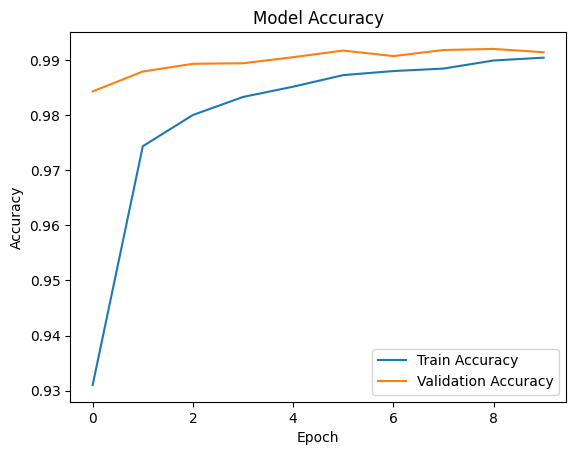

In [27]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [28]:
# Make predictions
# Predict on first test image
prediction = model.predict(x_test[:1])

# Convert probabilities → class label
predicted_label = np.argmax(prediction)

print(f"Predicted Label: {predicted_label}")
print(f"Actual Label: {y_test[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
Predicted Label: 7
Actual Label: 7
